<a href="https://colab.research.google.com/github/i-malur/bootcamp-dados-desafio-python-4/blob/main/%5BOFICIAL%5D_Bootcamp_Modulo9_challenge_testes_de_hip%C3%B3teses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.power import FTestAnovaPower

In [ ]:
url = 'https://raw.githubusercontent.com/Squad-Dorothy-Vaughan/Challenge-Teste-de-Hipotese/refs/heads/main/desafio_03_suplementos.csv'
df_suplementos = pd.read_csv(url)
df_suplementos.head()

,id_produto,id_atleta,ganho_massa,idade,frequencia_treino
0,Fórmula 3,1,2.24,27,5
1,Fórmula 1,2,4.97,35,4
2,Fórmula 3,3,0.88,30,6
3,Fórmula 3,4,0.09,22,6
4,Fórmula 1,5,2.47,18,6


In [ ]:
print('informações básicas do dataframe:')

print('-'*90)
print('\n\ntipos de dados de cada coluna:')
df_suplementos.info()

print('-'*90)
print('\n\nverificando valores vazios')
print(df_suplementos.isnull().sum())

print('-'*90)
print('\n\nlinhas e colunas do dataframe')
print(df_suplementos.shape)

print('-'*90)
print('\n\nestatísticas do dataframe')
df_suplementos.drop(columns=['id_atleta']).describe()

informações básicas do dataframe:
------------------------------------------------------------------------------------------


tipos de dados de cada coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_produto         300 non-null    object 
 1   id_atleta          300 non-null    int64  
 2   ganho_massa        300 non-null    float64
 3   idade              300 non-null    int64  
 4   frequencia_treino  300 non-null    int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 11.8+ KB
------------------------------------------------------------------------------------------


verificando valores vazios
id_produto           0
id_atleta            0
ganho_massa          0
idade                0
frequencia_treino    0
dtype: int64
------------------------------------------------------------------------------------------


,ganho_massa,idade,frequencia_treino
count,300.000000,300.000000,300.000000
mean,2.466733,28.123333,3.993333
std,1.436384,6.493742,1.430657
min,0.030000,18.000000,2.000000
25%,1.267500,22.000000,3.000000
50%,2.400000,28.000000,4.000000
75%,3.612500,34.000000,5.000000
max,4.980000,39.000000,6.000000


# Questão 01:

Faça uma análise exploratória dos dados:

* Qual é a média e a mediana do ganho de massa para cada
suplemento?

* Como os dados estão distribuídos? Utilize histogramas e
boxplots para visualizar as diferenças entre as fórmulas.

* Há outliers no ganho de massa muscular? O que isso pode
indicar?

In [ ]:
# Qual é a média e a mediana do ganho de massa para cada suplemento?

# estatísticas
df_medias = df_suplementos.groupby('id_produto')['ganho_massa'].agg(
    media='mean',
    mediana='median',
    desvio='std',
    minimo='min',
    maximo='max'
).round(2)

df_medias

,media,mediana,desvio,minimo,maximo
id_produto,,,,,
Fórmula 1,2.66,2.67,1.39,0.09,4.98
Fórmula 2,2.35,2.15,1.40,0.03,4.98
Fórmula 3,2.39,2.35,1.51,0.08,4.97


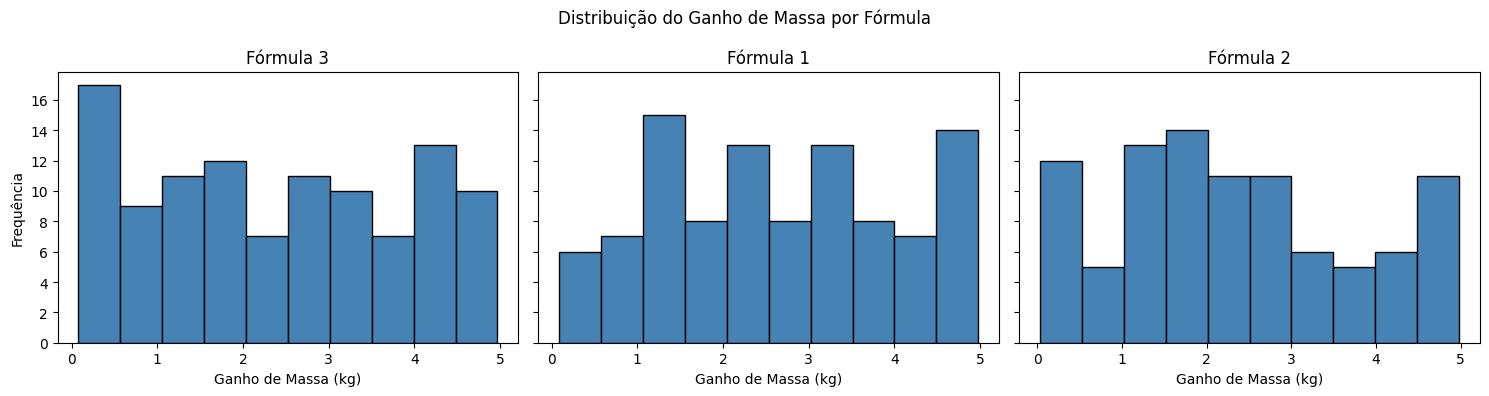

In [ ]:
# Como os dados estão distribuídos? Utilize histogramas e boxplots para visualizar as diferenças entre as fórmulas.
# Histogramas
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

formulas = df_suplementos['id_produto'].unique()

for ax, prod in zip(axes, formulas):
    subset = df_suplementos[df_suplementos['id_produto'] == prod]['ganho_massa']
    ax.hist(subset, bins=10, color='steelblue', edgecolor='black')
    ax.set_title(prod)
    ax.set_xlabel('Ganho de Massa (kg)')

axes[0].set_ylabel('Frequência')
plt.suptitle('Distribuição do Ganho de Massa por Fórmula')
plt.tight_layout()
plt.show()



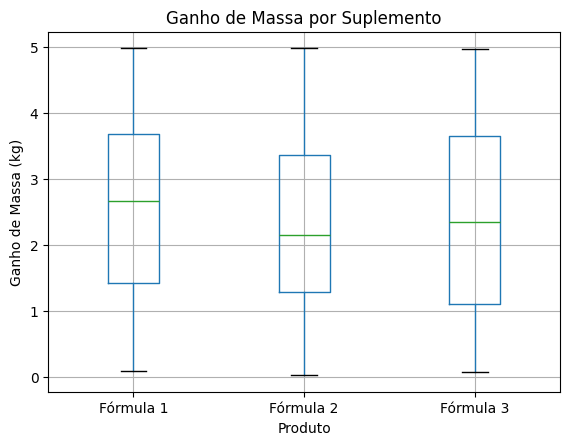

In [ ]:
figsize=(10, 3)
df_suplementos.boxplot(column='ganho_massa', by='id_produto')
plt.title('Ganho de Massa por Suplemento')
plt.suptitle('')
plt.xlabel('Produto')
plt.ylabel('Ganho de Massa (kg)')
plt.show()

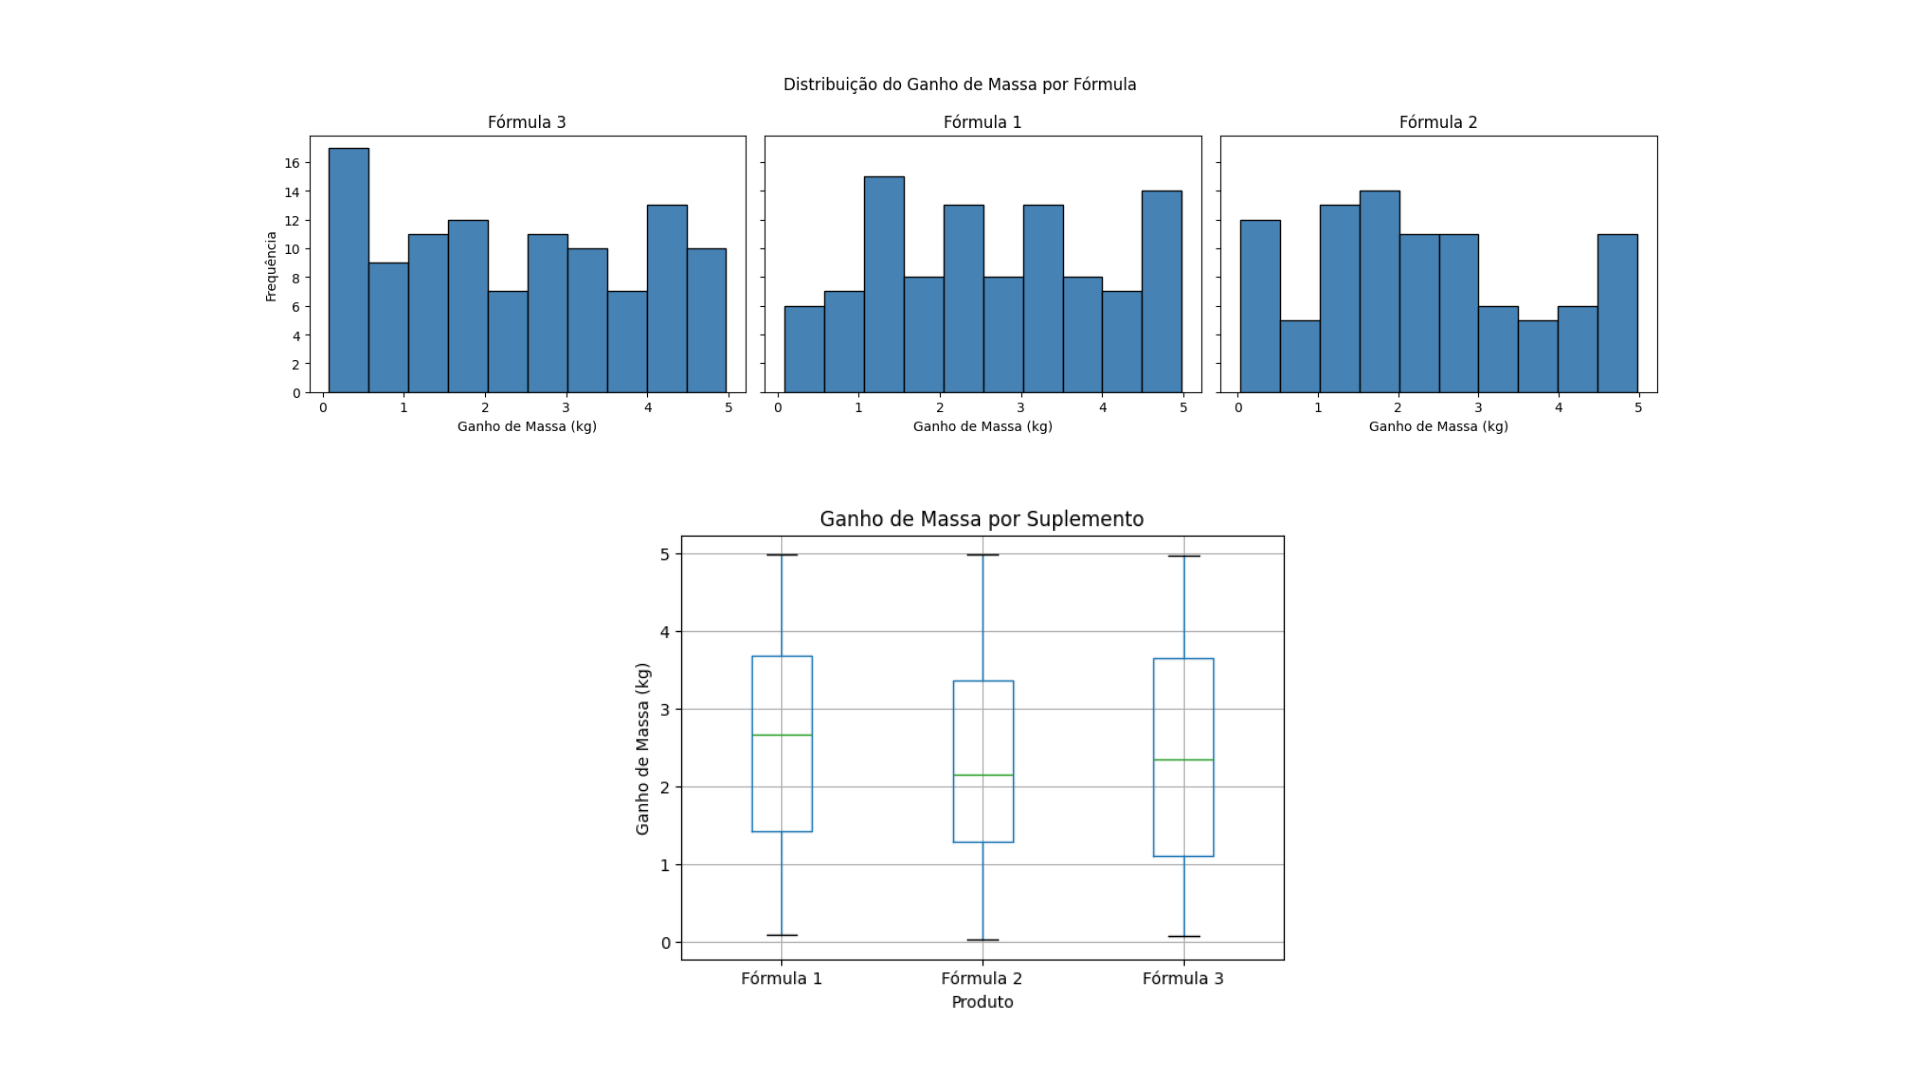

Ao comparar o ganho médio de massa muscular entre os três suplementos analisados, observa-se que a Fórmula 1 apresentou o melhor desempenho, com média de 2,66 kg e mediana de 2,67 kg. A proximidade entre esses dois valores indica uma distribuição relativamente simétrica dos resultados entre os atletas que utilizaram esse produto, ou seja, não há valores extremos puxando a média para cima ou para baixo de forma significativa.

A Fórmula 3 ficou em segundo lugar, com média de 2,39 kg e mediana de 2,35 kg. Assim como a Fórmula 1, a pequena diferença entre média e mediana sugere uma distribuição equilibrada dos ganhos de massa.

Já a Fórmula 2 apresentou o menor desempenho médio (2,35 kg), mas chama atenção a diferença mais acentuada entre média e mediana (2,35 kg vs. 2,15 kg). Esse padrão sugere uma leve assimetria à direita na distribuição dos dados: provavelmente existem alguns atletas com ganhos de massa consideravelmente mais altos que os demais, "puxando" a média para cima, enquanto a maior parte dos usuários teve resultados mais modestos, próximos da mediana.

Em nenhuma das três fórmulas foram identificados outliers, o que é visualmente confirmado pela ausência de pontos fora dos limites dos "bigodes" (whiskers) nos boxplots, reforçando que os dados, apesar das diferenças de forma e dispersão, não possuem valores extremos discrepantes.

Em termos práticos, isso significa que, embora a Fórmula 1 tenha o melhor resultado médio geral, a Fórmula 2 pode ter maior variabilidade de resposta entre indivíduos — o que seria interessante investigar com uma medida de dispersão (como desvio padrão) e uma análise de outliers mais detalhada

A análise visual por meio de histogramas, podemos observar diferenças no formato e na dispersão da distribuição do ganho de massa entre as três fórmulas de suplemento avaliadas.

A Fórmula 1 apresenta a distribuição mais simétrica e concentrada das três, com menor desvio padrão (1,39) ~e um coeficiente de assimetria próximo de zero (0,03)~. Isso se reflete tanto no histograma, com formato mais equilibrado em torno do centro, quanto no boxplot, onde a linha da mediana aparece bem centralizada dentro da caixa, indicando resultados mais previsíveis entre os atletas.

A Fórmula 2 se destaca por apresentar a maior assimetria entre as três (skew de 0,28), com uma leve cauda à direita no histograma, ou seja, a maioria dos atletas obteve ganhos mais modestos, enquanto uma minoria alcançou valores consideravelmente mais altos. Essa característica também aparece no boxplot, com a mediana deslocada para a parte inferior da caixa, evidenciando essa concentração de valores baixos com poucos casos de ganho elevado puxando a distribuição para cima.

Já a Fórmula 3 apresenta a maior dispersão entre as fórmulas (desvio padrão de 1,51), o que se traduz em uma caixa mais alta no boxplot e um histograma mais espalhado ao longo do eixo de ganho de massa. Apesar dessa maior variabilidade, sua distribuição permanece relativamente simétrica (skew de 0,08).

Em termos práticos, essas diferenças sugerem que a Fórmula 1 oferece o resultado mais consistente e previsível entre os atletas, enquanto a Fórmula 3 apresenta maior variabilidade de resposta, e a Fórmula 2 tem uma resposta mais heterogênea, com potencial de ganhos mais altos em uma parcela menor dos usuários.

In [ ]:
# Há outliers no ganho de massa muscular? O que isso pode indicar?

# Verificação de outliers - Método IQR

# Geral (todas as fórmulas juntas)
Q1 = df_suplementos['ganho_massa'].quantile(0.25)
Q3 = df_suplementos['ganho_massa'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_geral = df_suplementos[(df_suplementos['ganho_massa'] < lim_inf) |
                                  (df_suplementos['ganho_massa'] > lim_sup)]

print(f"Geral: limites [{lim_inf:.2f}, {lim_sup:.2f}] -> {len(outliers_geral)} outliers")

# Por fórmula
print()
for prod in df_suplementos['id_produto'].unique():
    subset = df_suplementos[df_suplementos['id_produto'] == prod]['ganho_massa']

    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = subset[(subset < lim_inf) | (subset > lim_sup)]

    print(f"{prod}: limites [{lim_inf:.2f}, {lim_sup:.2f}] | "
          f"min={subset.min():.2f}, max={subset.max():.2f} | outliers={len(outliers)}")

Geral: limites [-2.25, 7.13] -> 0 outliers

Fórmula 3: limites [-2.69, 7.45] | min=0.08, max=4.97 | outliers=0
Fórmula 1: limites [-1.96, 7.06] | min=0.09, max=4.98 | outliers=0
Fórmula 2: limites [-1.83, 6.47] | min=0.03, max=4.98 | outliers=0


Há outliers no ganho de massa muscular? O que isso pode indicar?
Aplicando o método do Intervalo Interquartil (IQR), tanto no conjunto geral quanto separadamente para cada fórmula, não foram identificados outliers no ganho de massa muscular. Os limites calculados (Q1 − 1,5×IQR e Q3 + 1,5×IQR) ficaram sempre bem além dos valores mínimos e máximos observados nos dados, ou seja, nenhum atleta apresentou um resultado extremo o suficiente para ser considerado atípico.

Essa ausência de outliers pode indicar algumas coisas:

Consistência na resposta ao tratamento: os atletas, independente da fórmula usada, tiveram ganhos de massa dentro de uma faixa relativamente previsível,  sem casos de resposta extraordinariamente alta (efeito muito acima do esperado) ou extraordinariamente baixa (não-resposta completa ou possível efeito adverso).
Boa qualidade/controle dos dados: a ausência de outliers também pode refletir que a coleta foi bem controlada, sem erros de registro (como digitação incorreta) ou situações atípicas de coleta.
Amplitude natural pequena: como os valores variam de aproximadamente 0 a 5 kg, a variabilidade absoluta já é pequena, o que reduz a chance estatística de um valor se destacar como extremo.



Cautela interpretativa: a ausência de outliers não significa que não existam diferenças relevantes entre indivíduos, só significa que essas diferenças, mesmo existindo (como a leve assimetria vista na Fórmula 2), não são extremas o suficiente para serem classificadas como atípicas pelos critérios estatísticos usuais (IQR ou Z-Score).

Em resumo: os dados sugerem uma resposta relativamente homogênea e sem anomalias graves entre os atletas, o que é um bom indicativo tanto da qualidade da base de dados quanto da consistência do efeito dos suplementos avaliados.

# Questão 02:

Há diferença estatiscamente significativa no ganho de massa muscular entre as três fórmulas?

Passo a passo do raciocínio:
1. Verificar normalidade (Shapiro-Wilk) — decide se usamos teste paramétrico ou não-paramétrico:

In [ ]:
for prod in df_suplementos['id_produto'].unique():
    subset = df_suplementos[df_suplementos['id_produto'] == prod]['ganho_massa']
    stat, p = stats.shapiro(subset)
    print(f"{prod}: p-valor = {p:.4f}")

Fórmula 3: p-valor = 0.0002
Fórmula 1: p-valor = 0.0036
Fórmula 2: p-valor = 0.0018


Resultado: todas as três fórmulas tiveram p < 0,05 → nenhuma segue distribuição normal. Isso já indica que o teste não-paramétrico é o mais apropriado.

2. Aplicar o teste de Kruskal-Wallis (equivalente não-paramétrico da ANOVA, comparando 3+ grupos):

In [ ]:
grupos = [df_suplementos[df_suplementos['id_produto']==p]['ganho_massa']
          for p in df_suplementos['id_produto'].unique()]

h_stat, p_valor = stats.kruskal(*grupos)
print(f"H = {h_stat:.4f}, p-valor = {p_valor:.4f}")

H = 2.6473, p-valor = 0.2662


**Resultado:**

Para verificar se existe diferença estatisticamente significativa no ganho de massa muscular entre as três fórmulas de suplemento, foi necessário primeiro avaliar se os dados seguem distribuição normal, já que essa condição determina qual teste estatístico é o mais apropriado. O teste de Shapiro-Wilk indicou que nenhuma das três fórmulas apresenta distribuição normal (p < 0,05 em todos os casos), o que torna o teste de Kruskal-Wallis, a alternativa não-paramétrica à ANOVA, a escolha mais adequada para essa comparação.

O teste de Kruskal-Wallis resultou em um p-valor de 0,266. Como esse valor é maior que o nível de significância convencional de 0,05, não há evidência estatística suficiente para afirmar que existe diferença significativa no ganho de massa muscular entre as três fórmulas de suplemento. Ou seja, do ponto de vista estatístico, as diferenças observadas nas médias (2,66 kg, 2,35 kg e 2,39 kg) podem ser atribuídas à variação natural amostral, e não a um efeito real e consistente de uma fórmula ser superior às demais.

Na prática, isso significa que, apesar da Fórmula 1 ter apresentado o maior ganho médio observado na amostra, não é possível concluir com confiança estatística que ela é de fato mais eficaz que as outras duas, a diferença encontrada pode simplesmente ser fruto do acaso na amostragem.


# Questão 03:

Existe correlação entre idade e ganho de massa muscular? Atletas
mais jovens ou mais velhos têm resultados diferentes?

In [ ]:
r_pearson, p_pearson = stats.pearsonr(df_suplementos['idade'], df_suplementos['ganho_massa'])
print(f"Pearson: r = {r_pearson:.4f}, p-valor = {p_pearson:.4f}")

r_spearman, p_spearman = stats.spearmanr(df_suplementos['idade'], df_suplementos['ganho_massa'])
print(f"Spearman: r = {r_spearman:.4f}, p-valor = {p_spearman:.4f}")

Pearson: r = -0.0733, p-valor = 0.2052
Spearman: r = -0.0768, p-valor = 0.1847


In [ ]:
df_suplementos['faixa_etaria'] = pd.cut(
    df_suplementos['idade'],
    bins=[17, 24, 31, 39],
    labels=['18-24 (jovens)', '25-31 (médio)', '32-39 (mais velhos)']
)

print(df_suplementos.groupby('faixa_etaria', observed=True)['ganho_massa'].agg(['mean', 'median', 'count']))

                         mean  median  count
faixa_etaria                                
18-24 (jovens)       2.571429    2.50    105
25-31 (médio)        2.493333    2.32     87
32-39 (mais velhos)  2.343519    2.19    108


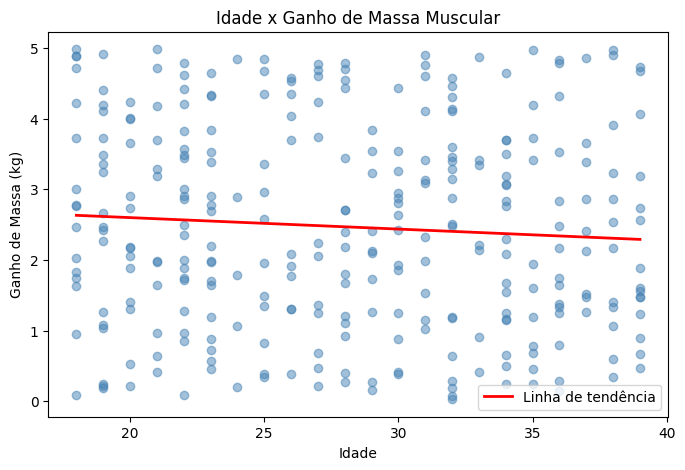

In [ ]:
plt.figure(figsize=(8, 5))

# Scatter plot
plt.scatter(df_suplementos['idade'], df_suplementos['ganho_massa'], alpha=0.5, color='steelblue')

# Linha de tendência (regressão linear)
z = np.polyfit(df_suplementos['idade'], df_suplementos['ganho_massa'], 1)
linha_tendencia = np.poly1d(z)
x_range = np.linspace(df_suplementos['idade'].min(), df_suplementos['idade'].max(), 100)
plt.plot(x_range, linha_tendencia(x_range), color='red', linewidth=2, label='Linha de tendência')

plt.xlabel('Idade')
plt.ylabel('Ganho de Massa (kg)')
plt.title('Idade x Ganho de Massa Muscular')
plt.legend()
plt.show()

**Resultado**:
A correlação entre idade e ganho de massa muscular é muito fraca e negativa (r de Pearson = -0,073; r de Spearman = -0,077), com p-valor acima de 0,05 em ambos os casos (0,205 e 0,185, respectivamente). Isso significa que não há evidência estatística de correlação significativa entre as duas variáveis, a idade, isoladamente, não parece influenciar de forma relevante o ganho de massa muscular nesta amostra.

Ao observar as médias por faixa etária, nota-se uma leve tendência de queda no ganho de massa conforme a idade aumenta (2,57 kg nos mais jovens contra 2,34 kg nos mais velhos), o que é coerente com o sinal negativo da correlação. No entanto, essa diferença é pequena e, dado que a correlação não é estatisticamente significativa, não é possível afirmar com confiança que se trata de um efeito real da idade, pode simplesmente refletir variação natural da amostra.

Na prática, isso sugere que fatores individuais (como frequência de treino, tipo de suplemento ou resposta metabólica pessoal) provavelmente têm mais peso no ganho de massa do que a idade do atleta dentro da faixa etária estudada (18 a 39 anos), uma faixa relativamente jovem e ativa, onde diferenças relacionadas ao envelhecimento tendem a ser menos pronunciadas do que seriam, por exemplo, em uma amostra que incluísse idosos.

# Questão 04:
Atletas que treinam mais frequentemente ganham mais massa
muscular independentemente do suplemento?

In [ ]:
#Correlação geral entre frequência de treino e ganho de massa

r_pearson, p_pearson = stats.pearsonr(df_suplementos['frequencia_treino'], df_suplementos['ganho_massa'])
r_spearman, p_spearman = stats.spearmanr(df_suplementos['frequencia_treino'], df_suplementos['ganho_massa'])

print(f"Pearson: r = {r_pearson:.4f}, p-valor = {p_pearson:.4f}")
print(f"Spearman: r = {r_spearman:.4f}, p-valor = {p_spearman:.4f}")

Pearson: r = 0.0787, p-valor = 0.1742
Spearman: r = 0.0737, p-valor = 0.2033


In [ ]:
#Verificar se o efeito é "independente do suplemento"
for prod in df_suplementos['id_produto'].unique():
    subset = df_suplementos[df_suplementos['id_produto'] == prod]
    r, p = stats.spearmanr(subset['frequencia_treino'], subset['ganho_massa'])
    print(f"{prod}: r = {r:.4f}, p-valor = {p:.4f}")

Fórmula 3: r = 0.1416, p-valor = 0.1456
Fórmula 1: r = 0.0473, p-valor = 0.6418
Fórmula 2: r = -0.0171, p-valor = 0.8701


In [ ]:
#Ver a média de ganho por nível de frequência de treino
print(df_suplementos.groupby('frequencia_treino')['ganho_massa'].agg(['mean', 'median', 'count']))

                       mean  median  count
frequencia_treino                         
2                  2.579672   2.640     61
3                  2.161000   2.075     60
4                  2.322540   2.170     63
5                  2.415000   2.445     52
6                  2.829687   2.705     64


<Figure size 900x500 with 0 Axes>

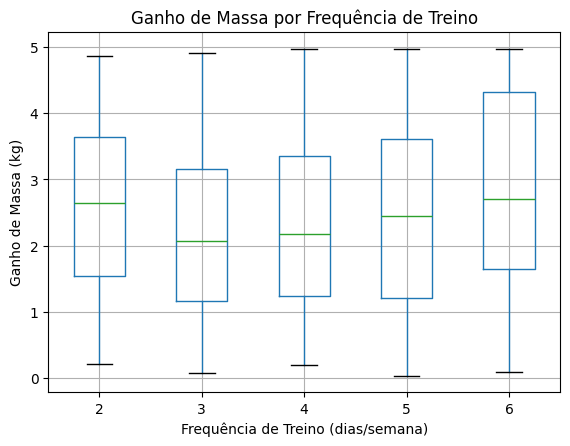

In [ ]:
plt.figure(figsize=(9, 5))
df_suplementos.boxplot(column='ganho_massa', by='frequencia_treino')
plt.title('Ganho de Massa por Frequência de Treino')
plt.suptitle('')
plt.xlabel('Frequência de Treino (dias/semana)')
plt.ylabel('Ganho de Massa (kg)')
plt.show()

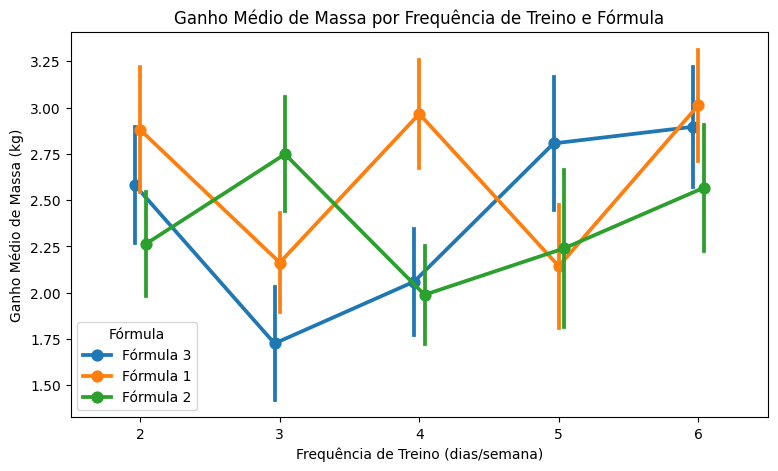

In [ ]:
plt.figure(figsize=(9, 5))
sns.pointplot(data=df_suplementos, x='frequencia_treino', y='ganho_massa', hue='id_produto',
              errorbar='se', dodge=True)
plt.title('Ganho Médio de Massa por Frequência de Treino e Fórmula')
plt.xlabel('Frequência de Treino (dias/semana)')
plt.ylabel('Ganho Médio de Massa (kg)')
plt.legend(title='Fórmula')
plt.show()

**Resposta**
A correlação entre frequência de treino e ganho de massa muscular é fraca e estatisticamente não significativa (r de Pearson = 0,079, p = 0,174; r de Spearman = 0,074, p = 0,203), considerando toda a amostra. Isso indica que, de forma geral, treinar com mais frequência não está associado a um ganho de massa proporcionalmente maior nesta base de dados.

Ao repetir essa análise separadamente para cada fórmula de suplemento, o resultado se mantém consistente: nenhuma das três fórmulas apresenta correlação significativa entre frequência de treino e ganho de massa (todos os p-valores acima de 0,05). A Fórmula 3 chega a ter a correlação mais alta das três (r = 0,142), mas ainda assim não significativa estatisticamente.

Olhando as médias por frequência de treino, também não há um padrão crescente claro, atletas que treinam 6 dias por semana têm a maior média (2,83 kg), mas os que treinam apenas 2 dias por semana têm a segunda maior média (2,58 kg), superando quem treina 3, 4 ou 5 dias. Essa ausência de tendência linear reforça que frequência de treino, isoladamente, não é um bom preditor de ganho de massa nesta amostra.

Respondendo diretamente à pergunta: não, os dados não sustentam a afirmação de que atletas que treinam mais frequentemente ganham mais massa muscular, independentemente do suplemento utilizado. A frequência de treino, dentro da faixa observada (2 a 6 dias/semana), não parece ser um fator determinante no ganho de massa, isso vale tanto para a amostra geral quanto quando se analisa cada fórmula separadamente. É importante destacar, porém, que este dataset não captura outras variáveis que também influenciam o ganho de massa muscular (como intensidade do treino, dieta, descanso, genética), então essa conclusão é restrita ao que os dados disponíveis permitem observar.

# Questão 05:
Existe alguma correlação entre idade, frequência de treino e a
eficácia do suplemento?

In [ ]:
#Matriz de correlação (idade, frequência de treino, ganho de massa)
correlacao = df_suplementos[['idade', 'frequencia_treino', 'ganho_massa']].corr(method='spearman')
print(correlacao)

                      idade  frequencia_treino  ganho_massa
idade              1.000000          -0.082534    -0.076785
frequencia_treino -0.082534           1.000000     0.073660
ganho_massa       -0.076785           0.073660     1.000000


In [ ]:
#Regressão múltipla — para ver o efeito combinado de idade e frequência de treino sobre o ganho de massa (a "eficácia" do suplemento), controlando uma variável pela outra ao mesmo tempo

X = df_suplementos[['idade', 'frequencia_treino']]
X = sm.add_constant(X)  # adiciona o intercepto
y = df_suplementos['ganho_massa']

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:            ganho_massa   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.605
Date:                Tue, 21 Jul 2026   Prob (F-statistic):              0.203
Time:                        01:46:39   Log-Likelihood:                -532.21
No. Observations:                 300   AIC:                             1070.
Df Residuals:                     297   BIC:                             1082.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.5924      0.45

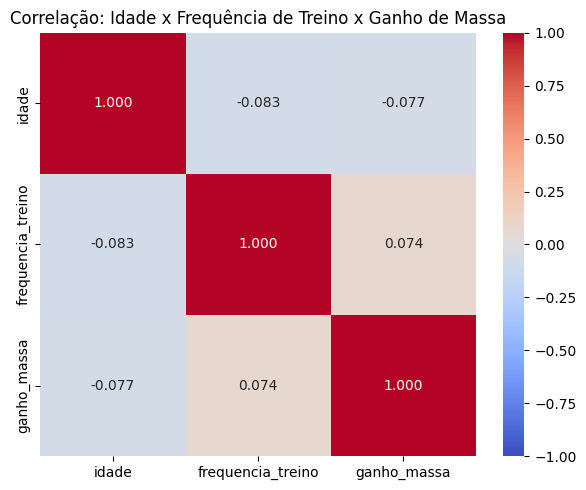

In [ ]:
correlacao = df_suplementos[['idade', 'frequencia_treino', 'ganho_massa']].corr(method='spearman')

plt.figure(figsize=(6, 5))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.3f')
plt.title('Correlação: Idade x Frequência de Treino x Ganho de Massa')
plt.tight_layout()
plt.show()

**Resposta:**
Nota metodológica: como o dataset não possui uma métrica explícita de "eficácia", essa variável foi operacionalizada neste trabalho como o ganho de massa muscular (ganho_massa) reportado por cada atleta. Essa escolha se justifica por ser a informação disponível mais diretamente ligada ao objetivo do suplemento (hipertrofia), mas é importante destacar que não há, no dataset, um grupo controle (atletas sem uso de suplemento) nem outras métricas de eficiência (como ganho por unidade de esforço) que permitiriam uma definição mais completa de eficácia.

Para investigar se há relação entre idade, frequência de treino e a eficácia do suplemento (medida pelo ganho de massa muscular), foram realizadas duas análises complementares: uma matriz de correlação entre as três variáveis e uma regressão linear múltipla, que avalia o efeito conjunto de idade e frequência de treino sobre o ganho de massa.

A matriz de correlação mostra que todas as relações entre as variáveis são muito fracas (coeficientes entre -0,08 e 0,07), o que já sinaliza ausência de associação relevante. Vale destacar também que idade e frequência de treino não estão correlacionadas entre si (r = -0,08, p = 0,154), ou seja, não há indício de que atletas mais jovens treinem mais (ou menos) que os mais velhos nesta amostra — o que simplifica a interpretação, já que não há um efeito de uma variável "disfarçando" a outra.

A regressão múltipla confirma esse cenário: o modelo como um todo explica apenas 1,1% da variação no ganho de massa (R² = 0,011), um valor extremamente baixo. Nenhuma das duas variáveis apresentou efeito estatisticamente significativo isoladamente dentro do modelo (idade: p = 0,246; frequência de treino: p = 0,208).

Respondendo diretamente à pergunta: não há evidência de correlação relevante entre idade, frequência de treino e a eficácia do suplemento (operacionalizada como ganho de massa) nesta amostra, seja analisando essas variáveis isoladamente ou em conjunto. Isso sugere que, dentro do que este dataset permite observar, a resposta ao suplemento é relativamente homogênea entre diferentes idades e frequências de treino — indicando que outros fatores não capturados nos dados (dieta, genética, tipo de treino, descanso, adesão ao uso do suplemento) provavelmente têm peso maior sobre a eficácia observada

# Questão 06:

Qual fórmula você recomendaria para atletas que treinam mais de 5
vezes por semana? Justifique sua escolha.

In [ ]:
# Filtrar atletas com frequência de treino > 5
subgrupo = df_suplementos[df_suplementos['frequencia_treino'] > 5]

# Estatísticas descritivas por fórmula dentro desse subgrupo
resultado = subgrupo.groupby('id_produto')['ganho_massa'].agg(['mean', 'median', 'std', 'count'])
print(resultado)

# Testar se a diferença é significativa dentro desse subgrupo
from scipy import stats
grupos = [subgrupo[subgrupo['id_produto']==p]['ganho_massa'] for p in subgrupo['id_produto'].unique()]
h, p_valor = stats.kruskal(*grupos)
print(f"Kruskal-Wallis: H={h:.4f}, p-valor={p_valor:.4f}")

                mean  median       std  count
id_produto                                   
Fórmula 1   3.012609   2.760  1.437884     23
Fórmula 2   2.566190   1.920  1.566137     21
Fórmula 3   2.896000   3.135  1.442773     20
Kruskal-Wallis: H=1.6719, p-valor=0.4335


**Resposta:**
Ao restringir a análise apenas aos atletas que treinam mais de 5 vezes por semana (n = 64, todos com frequência de 6 dias/semana, valor máximo registrado no dataset), observa-se que a Fórmula 1 apresenta o maior ganho médio de massa (3,01 kg), seguida de perto pela Fórmula 3 (2,90 kg), enquanto a Fórmula 2 apresenta o menor desempenho médio (2,57 kg) e também a maior dispersão relativa entre mediana e média, sinal de resultados mais heterogêneos dentro desse grupo.

Entretanto, ao aplicar o teste de Kruskal-Wallis dentro desse subgrupo específico, a diferença entre as três fórmulas não é estatisticamente significativa (H = 1,67, p = 0,434) — resultado consistente com a análise geral (pergunta 2), onde já havíamos constatado ausência de diferença significativa entre as fórmulas na amostra completa.

**Recomendação e justificativa:**

Com base nos dados disponíveis, eu recomendaria a Fórmula 1 para atletas que treinam mais de 5 vezes por semana, pelos seguintes motivos:

- Maior ganho médio observado nesse subgrupo (3,01 kg), ainda que a diferença não seja estatisticamente comprovada;
- Resposta historicamente mais consistente: na análise da amostra completa (pergunta 3), a Fórmula 1 apresentou a menor assimetria entre as três (skewness ≈ 0,03) e o menor desvio padrão, sinal de resposta mais previsível entre atletas — vale notar que, dentro deste subgrupo específico, a diferença entre média e mediana é semelhante à da Fórmula 3, então esse ponto se apoia mais no padrão geral da amostra do que neste subgrupo isolado;
- Ausência de outliers ou riscos aparentes, como confirmado na análise da pergunta 2.

É importante, porém, fazer uma ressalva metodológica: como a diferença entre fórmulas não atingiu significância estatística mesmo neste subgrupo, essa recomendação deve ser entendida como uma indicação baseada em tendência observada nos dados, e não como uma comprovação estatística robusta de superioridade da Fórmula 1. Isso também é parcialmente explicado pelo tamanho amostral reduzido do subgrupo (n = 64, contra n = 300 da amostra completa), o que reduz o poder estatístico do teste para detectar diferenças menores. Em um cenário real, a recomendação ideal seria acompanhada de uma coleta de dados adicional focada especificamente nesse perfil de atleta (treino ≥ 6x/semana), para aumentar a confiança estatística da conclusão.

# ADICIONAL

In [ ]:
# Subgrupo: atletas com frequência de treino > 5
subgrupo = df_suplementos[df_suplementos['frequencia_treino'] > 5]
grupos = [subgrupo[subgrupo['id_produto']==p]['ganho_massa'].values
          for p in subgrupo['id_produto'].unique()]

# 1. Calcular o tamanho de efeito observado (Cohen's f) a partir da ANOVA
f_stat, p_anova = stats.f_oneway(*grupos)
k = len(grupos)
n_total = sum(len(g) for g in grupos)
df_between, df_within = k - 1, n_total - k

eta_sq = (f_stat * df_between) / (f_stat * df_between + df_within)
cohens_f = np.sqrt(eta_sq / (1 - eta_sq))
print(f"Eta² = {eta_sq:.4f} | Cohen's f = {cohens_f:.4f}")

# 2. Calcular N necessário por grupo para poder estatístico de 80%
power_analysis = FTestAnovaPower()
n_necessario = power_analysis.solve_power(effect_size=cohens_f, k_groups=k, alpha=0.05, power=0.8)
print(f"N necessário por grupo: {n_necessario:.0f} | Total: {n_necessario*k:.0f}")

# 3. Poder estatístico ATUAL, com o tamanho de amostra que temos hoje
n_atual = np.mean([len(g) for g in grupos])
poder_atual = power_analysis.solve_power(effect_size=cohens_f, k_groups=k, nobs=n_atual, alpha=0.05)
print(f"Poder estatístico atual: {poder_atual*100:.1f}%")

Eta² = 0.0170 | Cohen's f = 0.1314
N necessário por grupo: 561 | Total: 1683
Poder estatístico atual: 7.4%


Para avaliar se a ausência de significância estatística se deve realmente à falta de diferença entre as fórmulas ou simplesmente ao tamanho reduzido da amostra, foi realizado um cálculo de poder amostral (power analysis) com base no tamanho de efeito observado (Cohen's f = 0,131, classificado como um efeito pequeno segundo os critérios de Cohen).

O resultado é revelador: com o tamanho de amostra atual (n ≈ 21 atletas por fórmula neste subgrupo), o poder estatístico do teste é de apenas 7,4%, muito abaixo do mínimo geralmente aceito de 80%. Isso significa que, mesmo que exista uma diferença real (porém pequena) entre as fórmulas, o teste atual tem baixíssima capacidade de detectá-la, tornando o resultado "não significativo" pouco conclusivo por si só.

Para atingir um poder estatístico adequado (80%) e detectar esse efeito pequeno com confiança, seriam necessários aproximadamente 561 atletas por fórmula (1.683 no total) — um número bem acima da amostra atual de apenas 64 atletas neste subgrupo específico.

Conclusão prática: a recomendação da Fórmula 1 apresentada anteriormente deve ser tratada como uma tendência exploratória, não uma conclusão estatisticamente validada. A não-significância do teste não é evidência de que as fórmulas são equivalentes — é, na verdade, um reflexo de amostra insuficiente para detectar diferenças pequenas nesse subgrupo específico. Para uma recomendação mais robusta, seria necessário um estudo com amostra bem maior, focado especificamente em atletas com alta frequência de treino (≥6x/semana).

# RESUMO (CONCLUSÃO)

Este estudo analisou o desempenho de três fórmulas de suplemento (Fórmula 1, 2 e 3) em relação ao ganho de massa muscular, com base em uma amostra de 300 atletas.

Conclusão geral: com os dados disponíveis, não é possível afirmar com confiança estatística que alguma fórmula seja superior às demais, nem que idade ou frequência de treino influenciem significativamente a resposta ao suplemento. As tendências observadas (favorecendo a Fórmula 1) podem orientar decisões práticas, mas devem ser tratadas como hipóteses a confirmar, não como conclusões definitivas.

**Limitações do Estudo**
1. Ausência de grupo controle:
O dataset não inclui atletas sem uso de suplemento. Sem esse grupo de comparação, não é possível isolar o efeito real do suplemento em relação ao ganho de massa que ocorreria naturalmente apenas com o treino.
2. Definição de "eficácia" como proxy:
A eficácia do suplemento foi operacionalizada como ganho de massa muscular bruto, por ser a métrica mais diretamente disponível no dataset. Essa definição não captura outras dimensões relevantes de eficácia, como ganho por unidade de esforço, tolerância, efeitos colaterais ou consistência de resposta entre indivíduos.
3. Tamanho amostral insuficiente em subgrupos:
Embora a amostra total (n=300) seja adequada para comparações gerais, subgrupos mais específicos (como atletas com frequência de treino >5x/semana, n=64) têm poder estatístico muito baixo (7,4%, conforme calculado na pergunta 6) para detectar diferenças pequenas entre fórmulas. Isso significa que resultados "não significativos" nesses subgrupos não devem ser interpretados como prova de equivalência entre as fórmulas.
4. Variáveis relevantes não capturadas:
O dataset não inclui informações sobre dieta, qualidade do sono, genética, nível de experiência de treino, adesão real ao uso do suplemento (dosagem, regularidade) ou tipo de treino realizado (força vs. hipertrofia vs. resistência), todos fatores conhecidos por influenciar ganho de massa muscular e que poderiam explicar variação não capturada pelas variáveis disponíveis.
5. Estudo observacional, não experimental:
Os dados não indicam se houve randomização na atribuição das fórmulas aos atletas. Sem randomização controlada, eventuais diferenças (ou semelhanças) entre grupos podem refletir características preexistentes dos atletas, não necessariamente o efeito do suplemento em si.
6. Janela etária restrita:
A amostra cobre atletas de 18 a 39 anos, uma faixa relativamente jovem e ativa. As conclusões sobre ausência de efeito da idade não podem ser generalizadas para populações mais velhas ou para atletas amadores fora dessa faixa etária.


**Próximos Passos**
Com base nas limitações identificadas neste estudo, sugerem-se os seguintes direcionamentos para pesquisas futuras sobre a eficácia das fórmulas de suplemento:
1. Incluir um grupo controle:
Recrutar um grupo de atletas com perfil de treino semelhante, mas sem uso de suplemento, permitindo isolar o efeito real do produto em relação ao ganho de massa esperado apenas pelo treino.
2. Aumentar a amostra em subgrupos específicos:
A análise de poder estatístico mostrou que seriam necessários aproximadamente 561 atletas por fórmula (1.683 no total) para detectar com confiança o efeito pequeno observado entre atletas de alta frequência de treino (>5x/semana). Estudos futuros deveriam priorizar o recrutamento direcionado a esse perfil, em vez de depender de subamostras extraídas de uma coleta geral.
3. Coletar variáveis adicionais relevantes:
Incorporar dados sobre dieta (ingestão calórica e proteica), qualidade e duração do sono, nível de experiência de treino, tipo de treino (força, hipertrofia, resistência) e adesão real ao uso do suplemento (dosagem e regularidade), fatores conhecidos por influenciar o ganho de massa muscular e ausentes no dataset atual.
4. Garantir randomização na atribuição das fórmulas:
Estruturar a coleta como um estudo experimental randomizado (idealmente duplo-cego), em que os atletas sejam alocados aleatoriamente a cada fórmula, reduzindo o risco de viés de seleção presente em estudos observacionais.
5. Ampliar a faixa etária da amostra:
Incluir atletas fora da faixa de 18-39 anos, permitindo avaliar se a ausência de efeito da idade se mantém em populações mais velhas ou em atletas amadores/iniciantes.
6. Definir métricas de eficácia mais completas:
Além do ganho de massa bruto, desenvolver métricas compostas de eficácia, por exemplo, ganho de massa ajustado por esforço (frequência × intensidade de treino), taxa de resposta (% de atletas com ganho acima de um limiar mínimo) e registro de efeitos colaterais reportados.
7. Reavaliar com testes de comparações múltiplas e ajuste de correção:
Em estudos futuros com amostra maior, aplicar testes post-hoc (como Dunn com correção de Bonferroni) para comparações par a par entre fórmulas, complementando o teste global de Kruskal-Wallis.